In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("C:\\Users\\rohin\\Sucide Project\\EDA READY DATA\\final_model_dataset_2000_onward_EDA_ready.csv")
df.head()

,Year,AlcoholConsumption,HomicideRate,GDP_per_capita,Current health expenditure (% of GDP)_x,Current health expenditure per capita (current US$)_x,"Unemployment, total (% of total labor force) (modeled ILO estimate)_x",SuicideRate,SuicideRate_Lower,SuicideRate_Upper
0,2000,8.742056,45.012212,3217.846934,7.336619,236.081146,22.714,13.132524,10.616174,15.492517
1,2001,8.742056,45.090413,2847.151919,7.123279,202.810654,22.605,13.245669,10.820065,15.693809
2,2002,8.483838,47.472567,2688.236760,6.677745,179.513550,22.547,14.598869,11.962040,17.234773
3,2003,8.366666,44.799503,4062.217560,7.040982,286.019989,22.629,15.759870,12.819716,18.513331
4,2004,8.343871,44.530240,5221.463337,6.938416,362.286621,22.538,16.074981,13.053871,18.851862


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 10 columns):
 #   Column                                                                 Non-Null Count  Dtype  
---  ------                                                                 --------------  -----  
 0   Year                                                                   25 non-null     int64  
 1   AlcoholConsumption                                                     25 non-null     float64
 2   HomicideRate                                                           25 non-null     float64
 3   GDP_per_capita                                                         25 non-null     float64
 4   Current health expenditure (% of GDP)_x                                25 non-null     float64
 5   Current health expenditure per capita (current US$)_x                  25 non-null     float64
 6   Unemployment, total (% of total labor force) (modeled ILO estimate)_x  25 non-null     float

In [5]:
df.describe()

,Year,AlcoholConsumption,HomicideRate,GDP_per_capita,Current health expenditure (% of GDP)_x,Current health expenditure per capita (current US$)_x,"Unemployment, total (% of total labor force) (modeled ILO estimate)_x",SuicideRate,SuicideRate_Lower,SuicideRate_Upper
count,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000
mean,2012.000000,8.289990,20.523564,6072.452899,7.788553,477.483766,25.815480,18.194975,14.689098,21.681880
std,7.359801,0.288134,12.800318,1506.921621,0.704280,136.513100,3.813187,2.800270,2.051062,3.514233
min,2000.000000,7.791870,12.533244,2688.236760,6.677745,179.513550,22.287000,13.132524,10.616174,15.492517
25%,2006.000000,8.239292,13.446773,5651.205852,7.123279,417.911743,22.605000,16.074981,13.053871,18.687917
50%,2012.000000,8.397732,13.955669,6523.410978,7.944344,503.467590,24.683000,18.186891,15.268520,22.167239
75%,2018.000000,8.451479,17.915438,6843.399419,8.103223,569.840759,27.035000,20.140313,16.563980,24.579817
max,2024.000000,8.742056,47.472567,8646.055711,9.013292,686.872437,34.007000,22.295801,17.174630,26.523387


In [6]:
df.isna().sum()

Year                                                                     0
AlcoholConsumption                                                       0
HomicideRate                                                             0
GDP_per_capita                                                           0
Current health expenditure (% of GDP)_x                                  0
Current health expenditure per capita (current US$)_x                    0
Unemployment, total (% of total labor force) (modeled ILO estimate)_x    0
SuicideRate                                                              0
SuicideRate_Lower                                                        0
SuicideRate_Upper                                                        0
dtype: int64

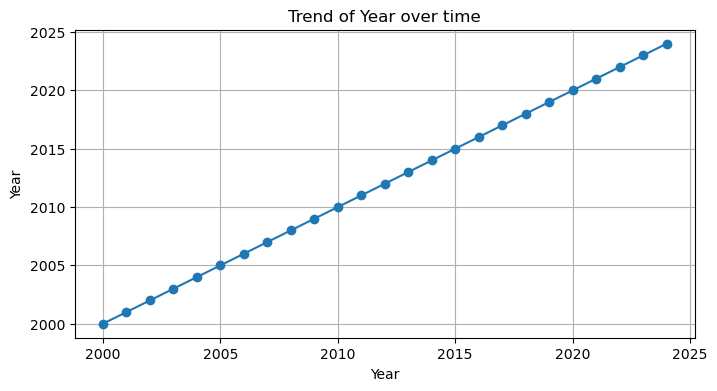

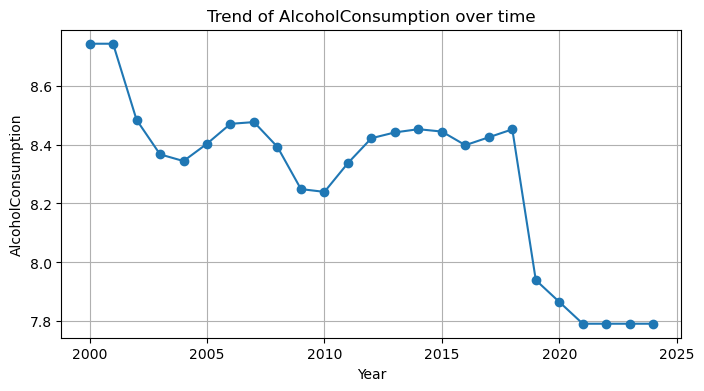

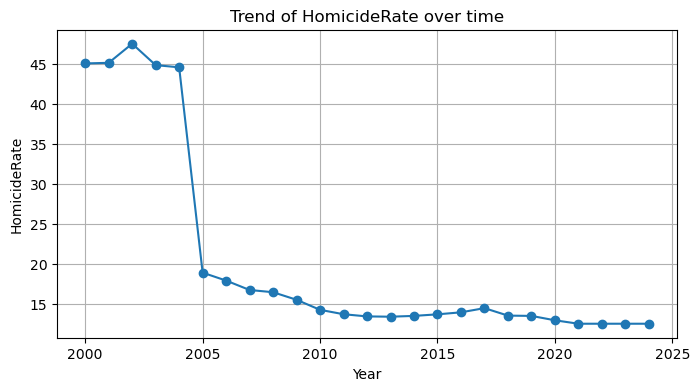

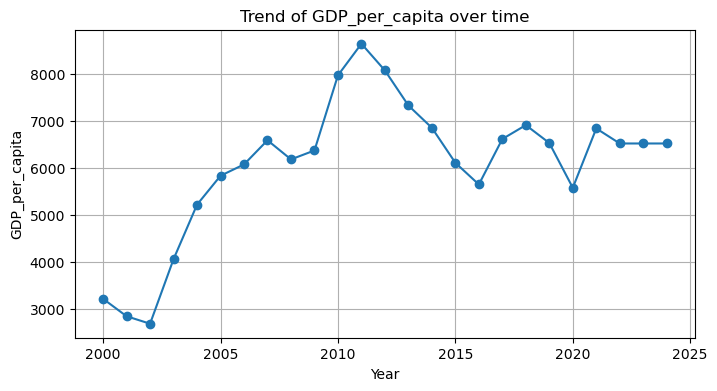

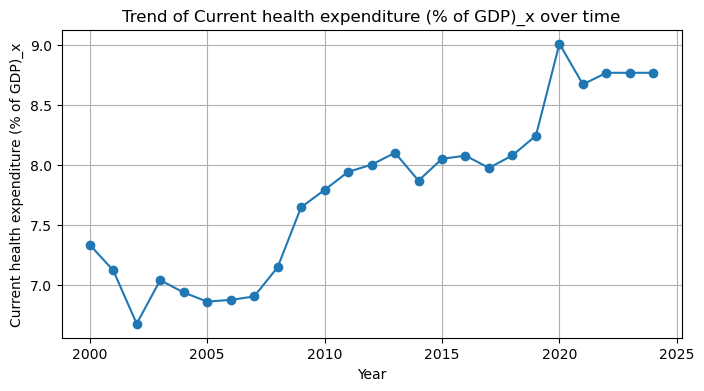

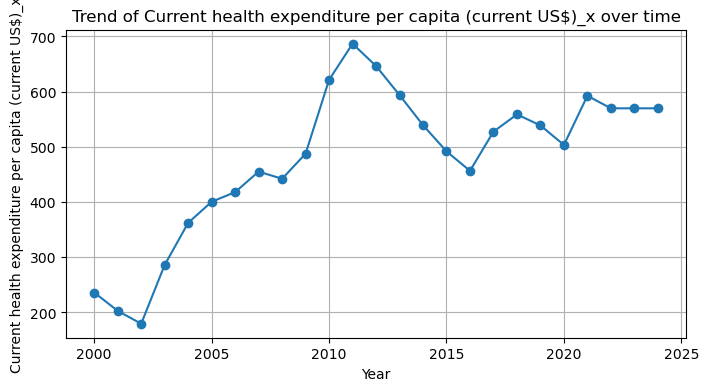

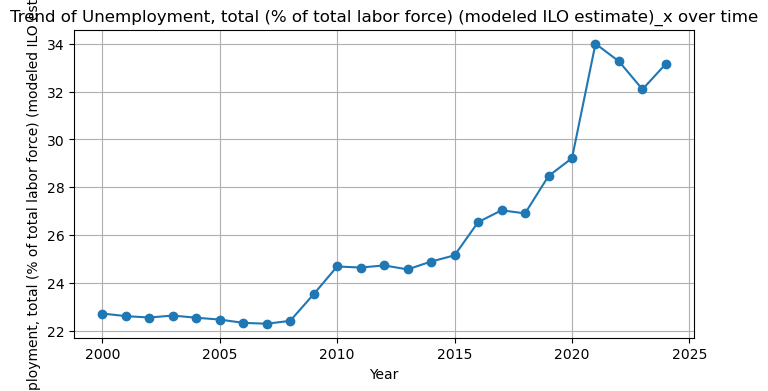

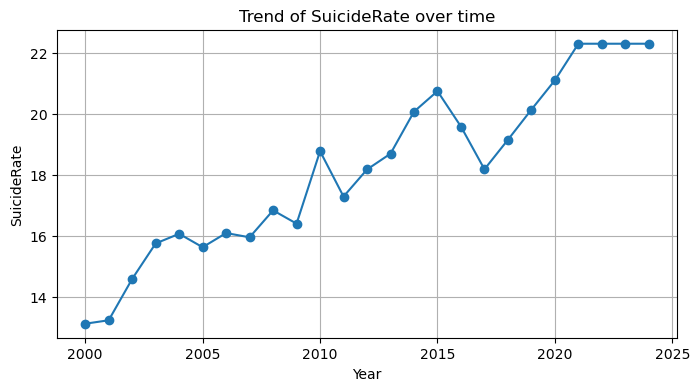

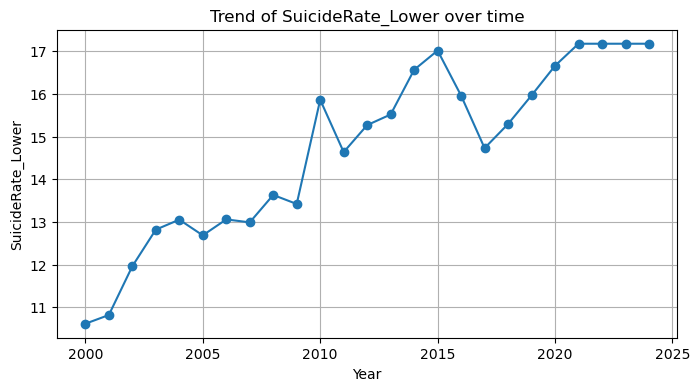

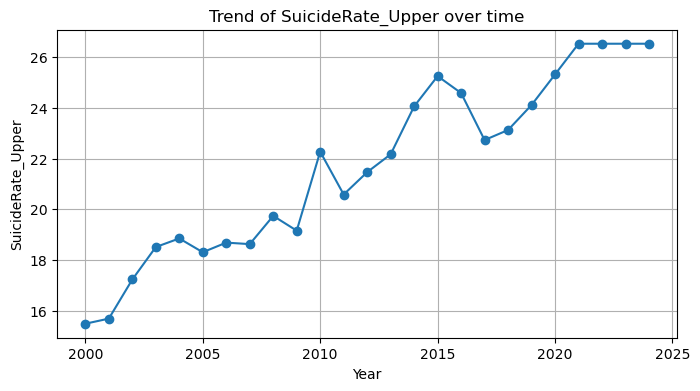

In [7]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

for col in numeric_cols:
    plt.figure(figsize=(8,4))
    plt.plot(df["Year"], df[col], marker="o")
    plt.title(f"Trend of {col} over time")
    plt.xlabel("Year")
    plt.ylabel(col)
    plt.grid(True)
    plt.show()

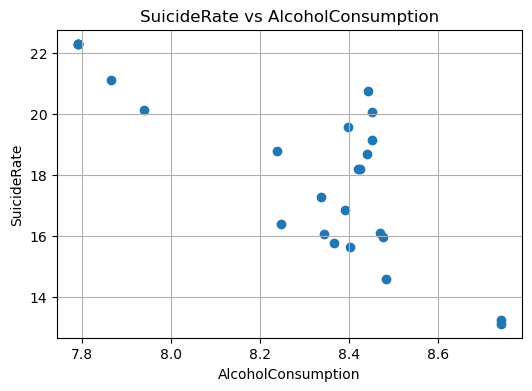

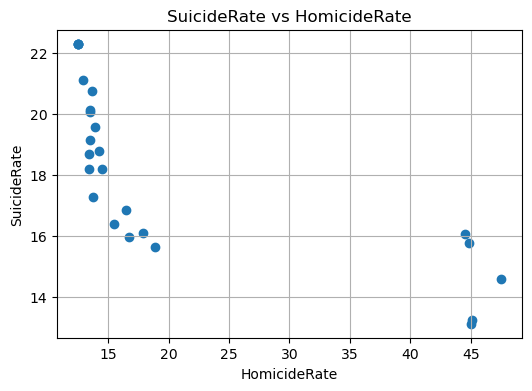

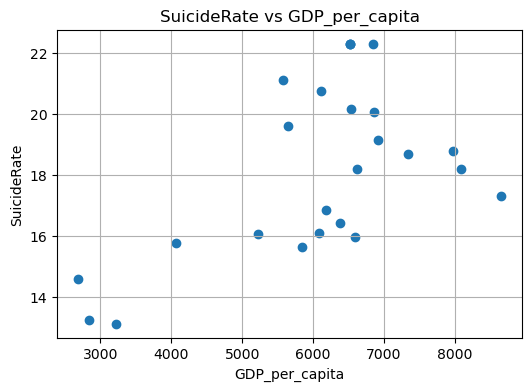

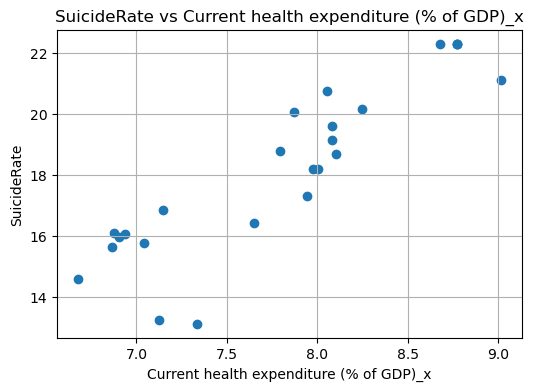

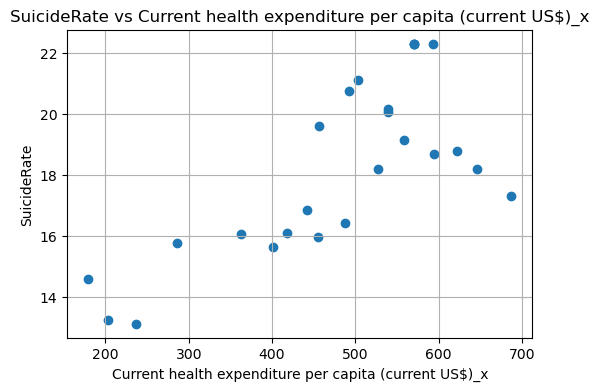

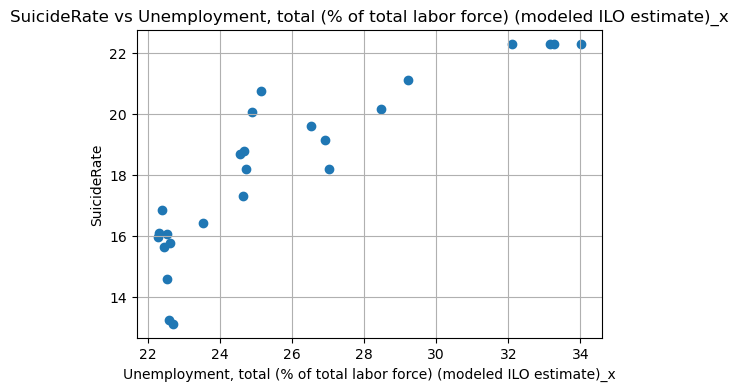

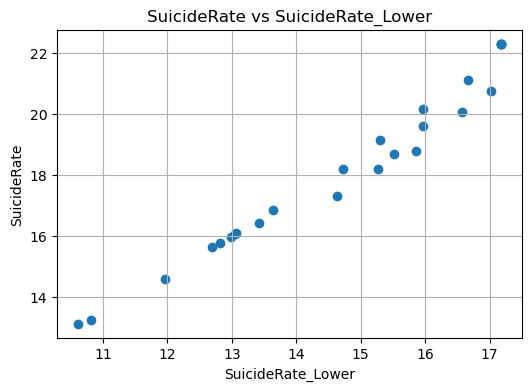

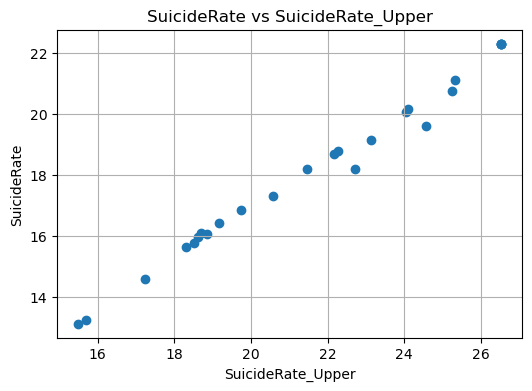

In [8]:
target = "SuicideRate"
predictors = [c for c in numeric_cols if c not in ["Year", target]]

for p in predictors:
    plt.figure(figsize=(6,4))
    plt.scatter(df[p], df[target])
    plt.title(f"{target} vs {p}")
    plt.xlabel(p)
    plt.ylabel(target)
    plt.grid(True)
    plt.show()

In [9]:
corr = df[numeric_cols].corr()
corr

,Year,AlcoholConsumption,HomicideRate,GDP_per_capita,Current health expenditure (% of GDP)_x,Current health expenditure per capita (current US$)_x,"Unemployment, total (% of total labor force) (modeled ILO estimate)_x",SuicideRate,SuicideRate_Lower,SuicideRate_Upper
Year,1.000000,-0.790674,-0.766405,0.563248,0.925225,0.739108,0.902579,0.959193,0.927967,0.964458
AlcoholConsumption,-0.790674,1.000000,0.494074,-0.361788,-0.752282,-0.524539,-0.870147,-0.813413,-0.735655,-0.773535
HomicideRate,-0.766405,0.494074,1.000000,-0.851853,-0.650898,-0.882720,-0.513037,-0.736964,-0.778341,-0.733415
GDP_per_capita,0.563248,-0.361788,-0.851853,1.000000,0.479950,0.962543,0.321153,0.566673,0.651376,0.548168
Current health expenditure (% of GDP)_x,0.925225,-0.752282,-0.650898,0.479950,1.000000,0.696436,0.888804,0.892933,0.869918,0.897305
Current health expenditure per capita (current US$)_x,0.739108,-0.524539,-0.882720,0.962543,0.696436,1.000000,0.536603,0.732508,0.795927,0.718171
"Unemployment, total (% of total labor force) (modeled ILO estimate)_x",0.902579,-0.870147,-0.513037,0.321153,0.888804,0.536603,1.000000,0.874200,0.790906,0.865777
SuicideRate,0.959193,-0.813413,-0.736964,0.566673,0.892933,0.732508,0.874200,1.000000,0.983220,0.993963
SuicideRate_Lower,0.927967,-0.735655,-0.778341,0.651376,0.869918,0.795927,0.790906,0.983220,1.000000,0.982002
SuicideRate_Upper,0.964458,-0.773535,-0.733415,0.548168,0.897305,0.718171,0.865777,0.993963,0.982002,1.000000
